In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines
import seaborn as sns
import glob
import os

import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

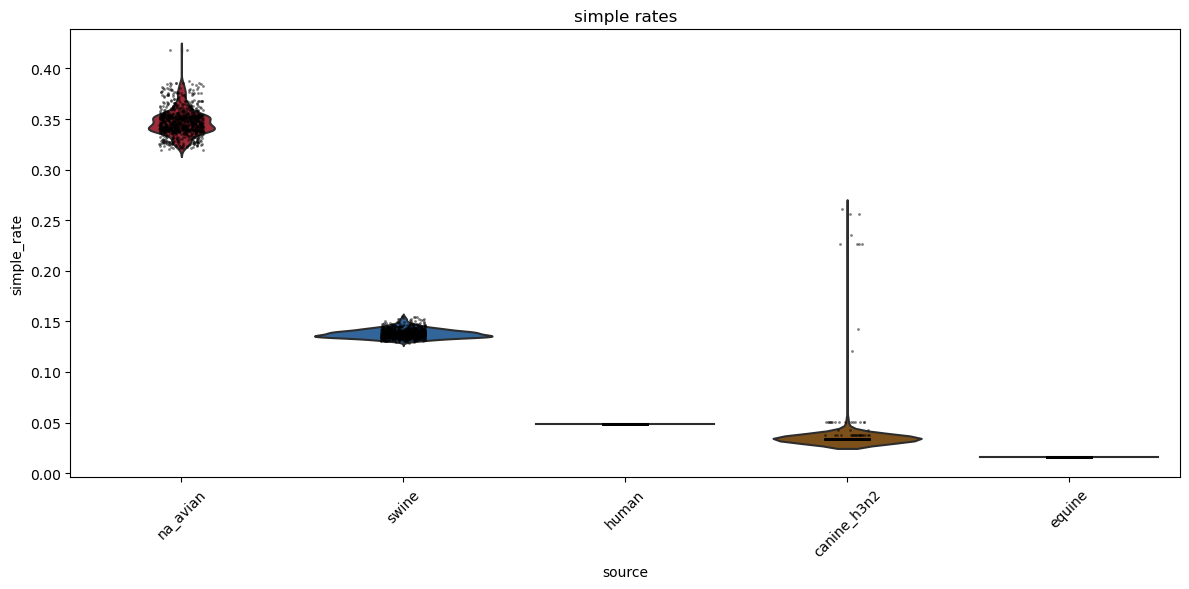

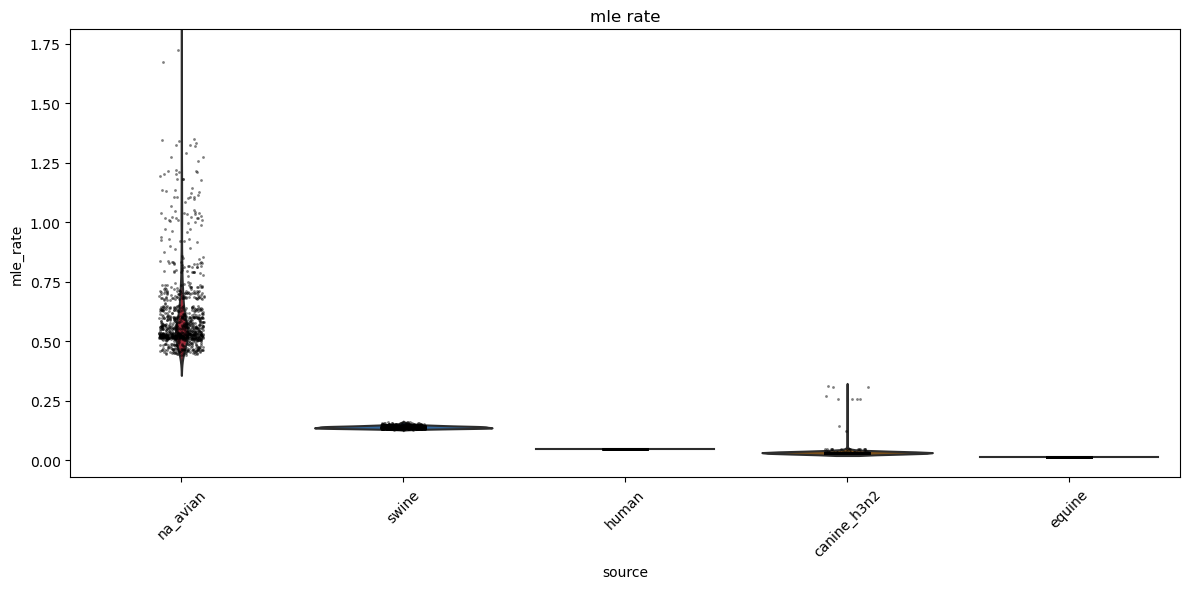

In [15]:
hosts = ["na_avian", "swine", "human", "canine_h3n2", "equine"]

host_colors = {
    "na_avian": "#b2182b",    
    "swine": "#2166ac",
    "human": "#92c5de",
    "canine_h3n2": "#8c510a",
    "equine": "#e78ac3"
}

files = glob.glob("logs-95/*.csv")
dfs = []
for f in files:
    df = pd.read_csv(f)
    host_name = os.path.basename(f).replace(".csv", "")
    df["source"] = host_name
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data["source"] = pd.Categorical(data["source"], categories=hosts, ordered=True)

# simple rate
plt.figure(figsize=(12, 6))
sns.violinplot(
    x="source", y="simple_rate",
    data=data, inner=None,
    palette=host_colors, order=hosts, dodge=False
)
sns.stripplot(
    x="source", y="simple_rate",
    data=data, color="k", size=2, jitter=True, alpha=0.5, order=hosts
)
plt.xticks(rotation=45)
plt.title("simple rates")
plt.tight_layout()
plt.legend([], [], frameon=False)
plt.show()

# mle rate
plt.figure(figsize=(12, 6))
sns.violinplot(
    x="source", y="mle_rate",
    data=data, inner=None,
    palette=host_colors, order=hosts, dodge=False
)
sns.stripplot(
    x="source", y="mle_rate",
    data=data, color="k", size=2, jitter=True, alpha=0.5, order=hosts
)
plt.xticks(rotation=45)
plt.title("mle rate")
plt.tight_layout()
plt.legend([], [], frameon=False)
plt.show()


In [14]:
from scipy.stats import f_oneway

files = glob.glob("logs-95/*.csv")

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["source"] = f  # tag file of origin
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# simple rate
groups_simple = [group["simple_rate"] for _, group in data.groupby("source")]
anova_simple = f_oneway(*groups_simple)
print("simple anova", anova_simple)

from scipy.stats import levene
print("simple levene", levene(*groups_simple))

print("\n")

# mle rate
groups_mle = [group["mle_rate"].dropna().values for _, group in data.groupby("source")]
anova_mle = f_oneway(*groups_mle)
print("mle anova", anova_mle)
print("mle levene", levene(*groups_mle))


simple anova F_onewayResult(statistic=156288.46614400955, pvalue=0.0)
simple levene LeveneResult(statistic=176.94814447638848, pvalue=3.629691289379363e-176)


mle anova F_onewayResult(statistic=10172.858308788967, pvalue=0.0)
mle levene LeveneResult(statistic=423.3243161282239, pvalue=0.0)
